# Heart Failure Prediction Dataset

--- 
## Descrição

As doenças cardiovasculares (DCVs) são a principal causa de morte em todo o mundo, ceifando cerca de 17,9 milhões de vidas a cada ano, o que representa 31% de todas as mortes no mundo. Quatro em cada cinco mortes por DCV são causadas por ataques cardíacos e derrames, e um terço dessas mortes ocorre prematuramente em pessoas com menos de 70 anos. A insuficiência cardíaca é um evento comum causado por DCVs e este conjunto de dados contém 11 características que podem ser usadas para prever uma possível doença cardíaca.

Pessoas com doenças cardiovasculares ou que apresentam alto risco cardiovascular (devido à presença de um ou mais fatores de risco, como hipertensão, diabetes, hiperlipidemia ou doença já estabelecida) precisam de detecção e tratamento precoces, e um modelo de aprendizado de máquina pode ser de grande ajuda.

Informações sobre Atributos
- Idade: idade do paciente [anos]
- Sexo: sexo do paciente [M: Masculino, F: Feminino]
- ChestPainType: tipo de dor torácica [AT: Angina Típica, ATA: Angina Atípica, NAP: Dor Não Anginal, ASY: Assintomático]
- RESSINGPAIN: pressão arterial em repouso [mm Hg]
- Colesterol: colesterol sérico [mm/dl]
- FastingBS: glicemia em jejum [1: se BS em jejum > 120 mg/dl, 0: caso contrário]
- RESSINGECG: resultados de eletrocardiograma em repouso [Normal: Normal, ST: com anormalidade da onda ST-T (inversões da onda T e/ou elevação ou depressão do segmento ST > 0,05 mV), HVE: mostrando hipertrofia ventricular esquerda provável ou definitiva pelos critérios de Estes]
- MaxHR: frequência cardíaca máxima atingida [valor numérico entre 60 e 202]
- ExerciseAngina: angina induzida por exercício [S: Sim, N: Não]
- Oldpeak: oldpeak = ST [Valor numérico medido na depressão]
- ST_Slope: a inclinação do pico do segmento ST do exercício [Up: ascendente, Flat: plano, Down: descendente]
- HeartDisease: classe de débito [1: doença cardíaca, 0: normal]


Link do Dataset: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data

---
## 1 - Importação das Bibliotecas e Leitura Inicial da Base

In [2]:
#Importe das libs necessárias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [5]:
#Adiciona base a um DF
df_original = pd.read_csv('heart.csv')

#Leitura inicial do DF
df_original.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


- Sexo, RestingECG, ExerciseAngina, ST_Slope: Será necessario tratamento, para variavel númerica ordinal

In [3]:
#Tamanho do DF
df_original.shape

(918, 12)

In [4]:
#Visualiza informações complementares (tipo dos dados, possivel ver quantidade de nulos, tamanho)
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
#Distribuição estatistica das variaveis numericas
df_original.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


- Age: Distribuição ok, sem nenhum pico fora do usual.
- RestingBP, Cholesterol, MaxHR: Aparentemente uma distribuição normal.
- FastingBS, HeartDisease: Valore entre 0 e 1
- Oldpeak: Apresenta valores negativos, ponto a ser investigado.

---
## 2 - Analise Grafica

In [6]:
#Separar DF em colunas categoricas x numericas
categ_columns = df_original.select_dtypes(include='object')
numeric_columns = df_original.select_dtypes(include=['int64', 'float64'])

### 2.1 - Boxplot


Um boxplot (ou gráfico de caixa e bigodes) mostra a distribuição de dados quantitativos de uma forma que facilita comparações entre variáveis ​​ou entre níveis de uma variável categórica. O gráfico de caixa mostra os quartis do conjunto de dados, enquanto os bigodes se estendem para mostrar o restante da distribuição, exceto para pontos que são determinados como "outliers" usando um método que é uma função do intervalo interquartil.

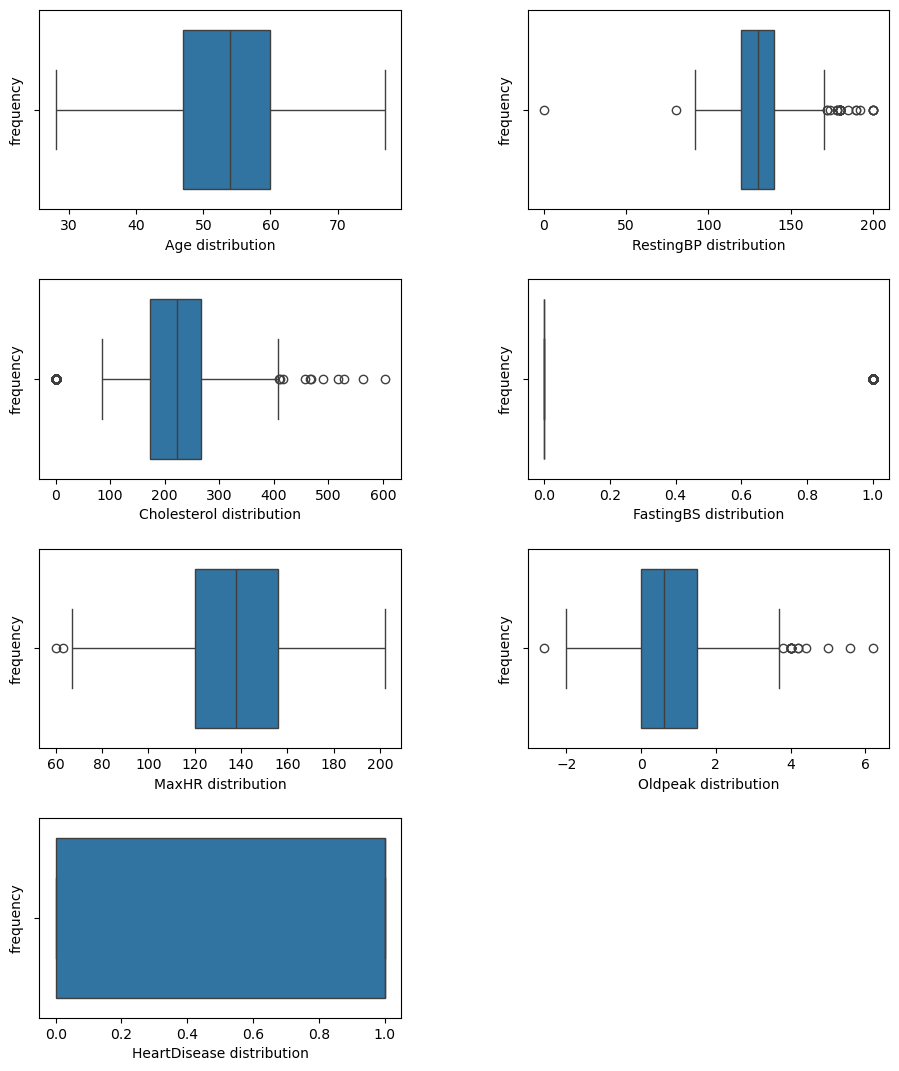

In [7]:
#Defini tamanho do Grafico
plt.figure(figsize=(10, 12))

#Grafico de BoxPlot
for i, col in enumerate(numeric_columns):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.boxplot(data=df_original, x=col)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()

### 2.2 - Violinplot

Um grafico de violino desempenha um papel semelhante ao grafico Boxplot. Ele mostra a distribuição dos pontos de dados após o agrupamento por uma (ou mais) variáveis. Ao contrário de um boxplot, cada violino é desenhado usando uma estimativa de densidade de kernel da distribuição subjacente

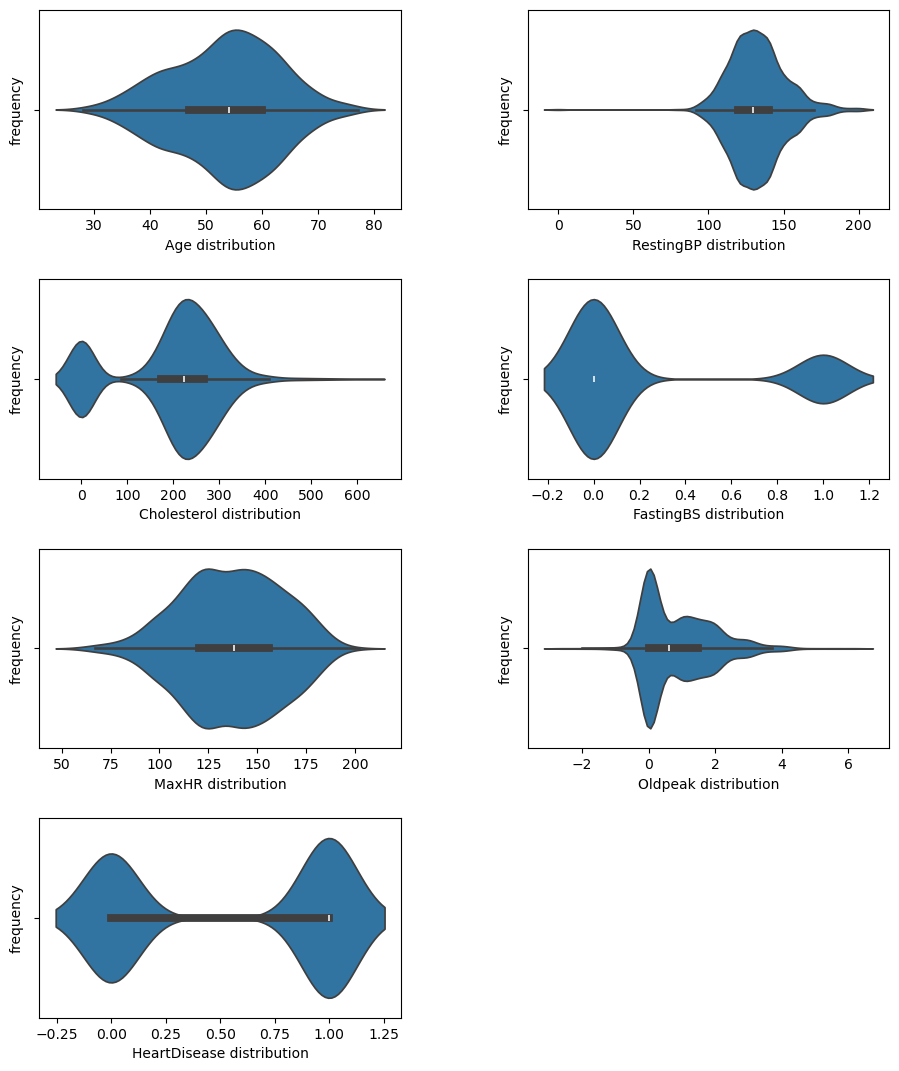

In [8]:
#Defini tamanho do Grafico
plt.figure(figsize=(10, 12))

#Grafico de BoxPlot
for i, col in enumerate(numeric_columns):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.violinplot(data=df_original, x=col)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()

### 2.3 - Histplot

Um histplot é uma ferramenta de visualização clássica que representa a distribuição de uma ou mais variáveis ​​contando o número de observações que se enquadram em compartimentos discretos.

Esta função pode normalizar a estatística calculada dentro de cada bin para estimar frequência, densidade ou massa de probabilidade, e pode adicionar uma curva suave obtida usando uma estimativa de densidade de kernel, semelhante a kdeplot().

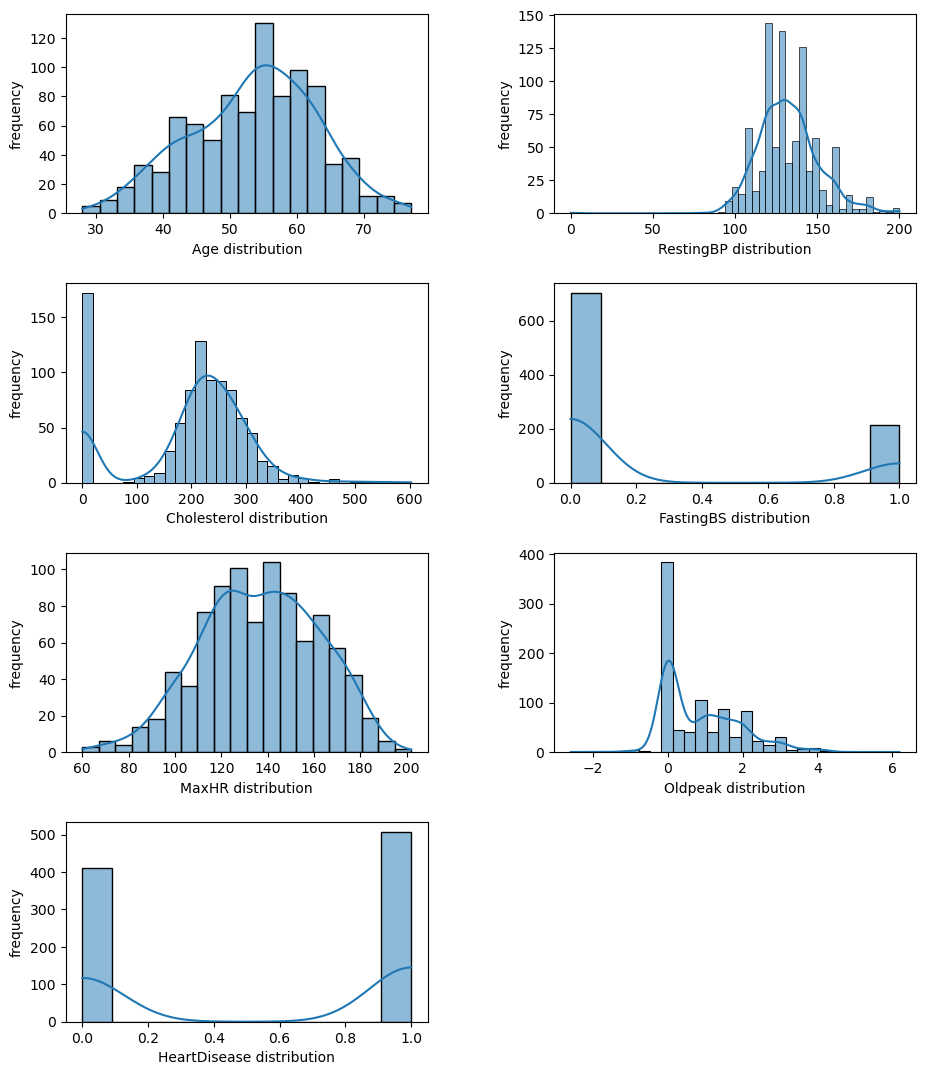

In [8]:
#Defini tamanho do Grafico
plt.figure(figsize=(10, 12))

#Grafico de BoxPlot
for i, col in enumerate(numeric_columns):
    idx = int('42' + str(i+1))
    plt.subplot(idx)
    sns.histplot(data=df_original, x=col, kde=True)
    plt.xlabel(col+ ' distribution')
    plt.ylabel('frequency')

#Ajusta espaçamento entre os gráficos
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.10, right=0.95, hspace=0.35, wspace=0.35)
plt.show()

---
## 3 - Implementação do modelo Regressão Logistica

### 3.1 - Divisão do DF

In [10]:
#Divisão em X e y
X = df_original.drop(['HeartDisease'], axis=1)
y = df_original['HeartDisease']

#Divisão em Train e Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y)

### 3.2 - Preprocessamento dos Dados

In [11]:
#Divisão das variaveis numericas e categoricas
categorical_features = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

numerical_features = [
    'Age',
    'RestingBP',
    'Cholesterol',
    'FastingBS',
    'MaxHR',
    'Oldpeak'
]

In [12]:
#Tranform categorica
categorical_transform = OneHotEncoder(handle_unknown='ignore')

#Tranform numerica
numeric_transform = StandardScaler()

In [13]:
#Implementação ColumnTransform
preprocessamento = ColumnTransformer(
    transformers=[
        ('num', numeric_transform, numerical_features),
        ('cat', categorical_transform, categorical_features)
    ]
)

### 3.3 - Implementação do Modelo e Metricas de Avaliação

In [14]:
#Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessamento),
    ('model', LogisticRegression(max_iter=1000))
])

In [15]:
#Fit do modelo
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'FastingBS',
                                                   'MaxHR', 'Oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [16]:
#Predict
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

#Metricas de avaliação do Modelo Regressão Logistica
print(classification_report(y_test, y_pred))
print('AUC', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

AUC 0.9299378287900525


In [17]:
#Matrix de Confusão
confusion_matrix(y_test, y_pred)

array([[68, 14],
       [ 7, 95]])

---
## 4 - Validação Cruzada

In [18]:
#Implementação da Validação Cruzada
cv_auc = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print('AUC por Fold:', cv_auc)
print('AUC Médio', np.mean(cv_auc))
print('Desvio Padrão', np.std(cv_auc))

AUC por Fold: [0.94081779 0.93938307 0.91846007 0.89471142 0.85124366]
AUC Médio 0.9089232022197915
Desvio Padrão 0.0333614276783346


In [19]:
#Implementação da Validação Cruzada com 10 folds
cv_auc = cross_val_score(
    pipeline,
    X,
    y,
    cv=10,
    scoring='roc_auc'
)

print('AUC por Fold:', cv_auc)
print('AUC Médio', np.mean(cv_auc))
print('Desvio Padrão', np.std(cv_auc))

AUC por Fold: [0.94117647 0.9689144  0.94261119 0.9713056  0.94500239 0.8866571
 0.94882831 0.85413678 0.85512195 0.87853659]
AUC Médio 0.9192290769966525
Desvio Padrão 0.0433738722435003


--- 
## 5 - Implementação do modelo Random Forrest

In [20]:
#Pipiline para o modelo RF
pipeline_rf = Pipeline(steps=[
    ('prepocessor', preprocessamento),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

### 5.1 - Validação Cruzada - Random Forrest

In [21]:
#Validação cruzada
cv_auc_rf = cross_val_score(
    pipeline_rf,
    X,
    y,
    cv=5,
    scoring='roc_auc'
)

print('AUC por Fold:', cv_auc_rf)
print('AUC Médio', np.mean(cv_auc_rf))
print('Desvio Padrão', np.std(cv_auc_rf))

AUC por Fold: [0.95139885 0.93747011 0.91266141 0.9033446  0.84442164]
AUC Médio 0.9098593216566992
Desvio Padrão 0.03693310711938147


---
## 6 - Interpretação do Modelo - Regressão Logistica

In [22]:
# Pegar modelo treinado
model = pipeline.named_steps['model']

# Pegar nomes das colunas após transformação
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Coeficientes
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coef': np.abs(coefficients)
}).sort_values(by='abs_coef', ascending=False)

coef_df.head(15)

,feature,coefficient,abs_coef
19,cat__ST_Slope_Up,-1.325803,1.325803
8,cat__ChestPainType_ASY,1.193180,1.193180
18,cat__ST_Slope_Flat,1.089095,1.089095
10,cat__ChestPainType_NAP,-0.642273,0.642273
6,cat__Sex_F,-0.635529,0.635529
7,cat__Sex_M,0.531010,0.531010
15,cat__ExerciseAngina_N,-0.502676,0.502676
2,num__Cholesterol,-0.492059,0.492059
9,cat__ChestPainType_ATA,-0.439494,0.439494
3,num__FastingBS,0.430936,0.430936
